# Student Mental Health Score Prediction

This project builds a regression model to predict a student's **Mental Health Score** from demographic information, social-media usage, daily routine, and stress level.

### Project workflow
1. Load and inspect the dataset
2. Perform exploratory data analysis (EDA)
3. Check data quality and outliers
4. Split the data into training and testing sets
5. Prepare features using preprocessing pipelines
6. Train and compare regression models
7. Tune the Random Forest model
8. Select and save the best model
9. Test the saved model on a new student

**Target variable:** `Mental_Health_Score`

In [104]:
# Import libraries used throughout the project
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn import set_config
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

set_config(display='diagram')
warnings.filterwarnings('ignore')

## 1. Import Libraries

Import the libraries needed for data manipulation, visualization, preprocessing, model training, and evaluation.

In [2]:
# Load the dataset
df = pd.read_csv('Students_mental_health.csv')

## 2. Load the Dataset

Read the CSV file into a pandas DataFrame so we can inspect and prepare the data.

In [3]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [4]:
df.shape

(5000, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [6]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

In [33]:
# Separate numerical and categorical columns for EDA
num_features = df.select_dtypes(include="number")
cat_features = df.select_dtypes(include="object")

print("Numerical Features:")
print(num_features)

print("\nCategorical Features:")
print(cat_features)

Numerical Features:
      Age  Avg_Daily_Usage_Hours  Daily_Unlocks  Study_Hours  \
0      21                    4.0            134          4.5   
1      23                    1.6             73          7.0   
2      22                    4.6            166          4.0   
3      18                    7.0            220          1.0   
4      24                    7.5            237          1.0   
...   ...                    ...            ...          ...   
4995   18                    1.9             89          6.1   
4996   18                    6.6            216          2.3   
4997   19                    3.8            151          5.4   
4998   18                    3.8            119          4.0   
4999   19                    5.4            177          1.2   

      Physical_Activity_Hours  Sleep_Hours_Per_Night  Mental_Health_Score  
0                         2.2                    6.7                  6.8  
1                         2.4                    8.6       

In [34]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [35]:
df.describe(include='object')

,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Stress_Level
count,5000,5000,5000,5000,5000,5000
unique,2,111,3,12,4,4
top,Male,Other,Undergraduate,Instagram,Entertainment,Very High
freq,2635,1880,3632,1130,2552,1621


In [36]:
for col in cat_features:
  print(f'\n{'='* 20}')
  print(f'Column : {col}')
  print(df[col].value_counts(dropna= False))


Column : Gender
Gender
Male      2635
Female    2365
Name: count, dtype: int64

Column : Country
Country
Other        1880
India         389
USA           355
Canada        230
Australia     198
             ... 
Armenia         1
Bosnia          1
Kuwait          1
Yemen           1
Syria           1
Name: count, Length: 111, dtype: int64

Column : Academic_Level
Academic_Level
Undergraduate    3632
Graduate          918
High School       450
Name: count, dtype: int64

Column : Most_Used_Platform
Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      523
YouTube       491
Twitter       462
Snapchat      420
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64

Column : Purpose_Of_Use
Purpose_Of_Use
Entertainment    2552
Education        1094
Networking        793
News              561
Name: count, dtype: int64

Column : Stress_Level
Stress_Level
Very High    1621
High         1440
Medium   

In [37]:
# Check for missing values in each column
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [38]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(2)

## 3. Initial Data Inspection

Inspect the shape, columns, data types, and summary statistics to understand the dataset before modelling.

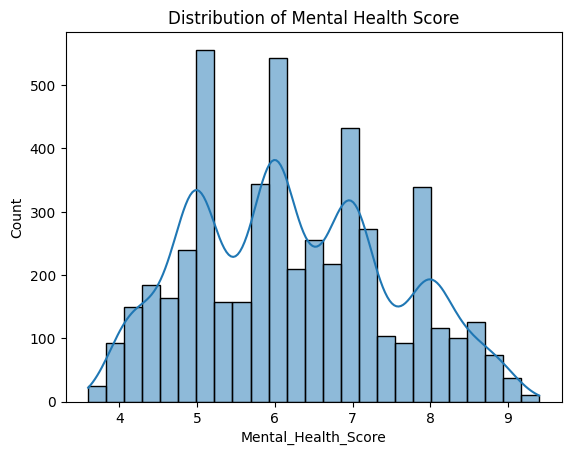

In [39]:
sns.histplot(df['Mental_Health_Score'], kde=True)
plt.title('Distribution of Mental Health Score')
plt.show()

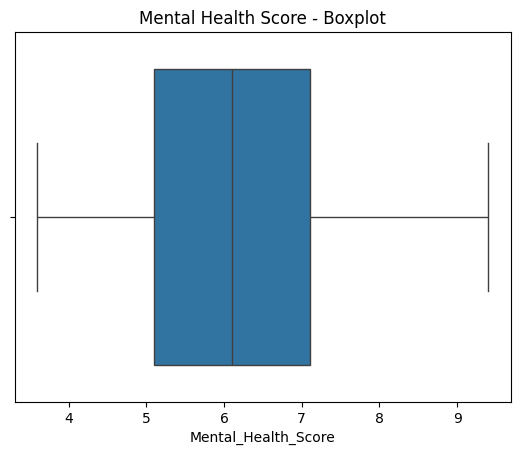

In [40]:
sns.boxplot(x=df['Mental_Health_Score'])
plt.title('Mental Health Score - Boxplot')
plt.show()

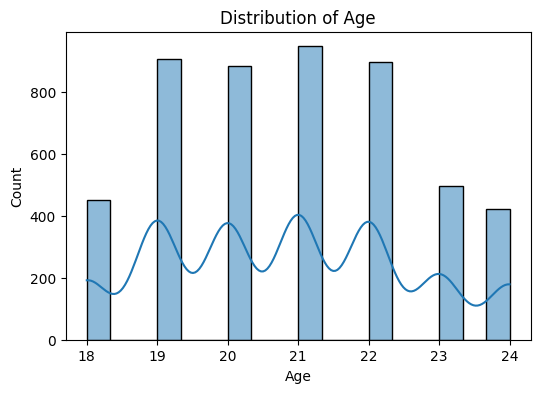

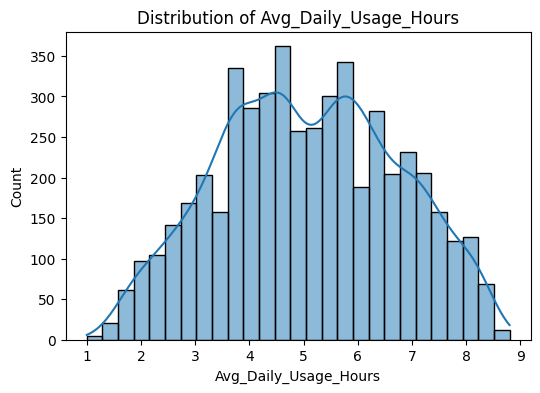

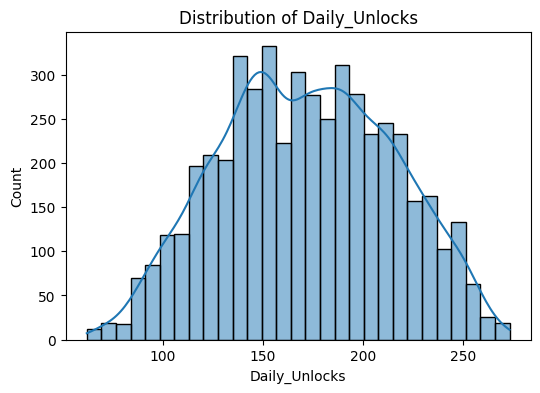

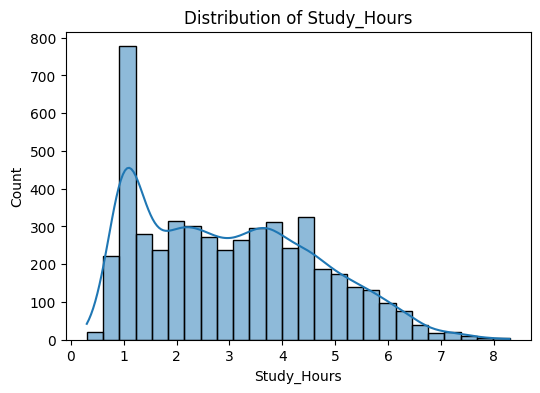

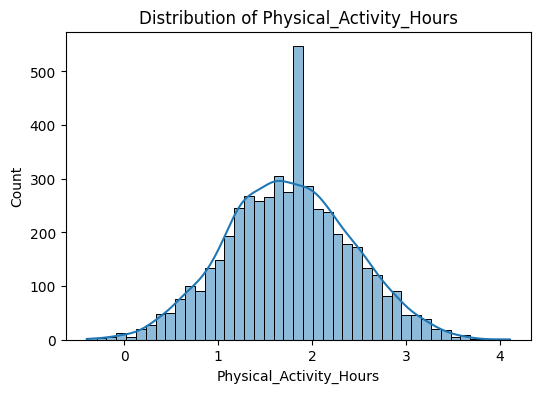

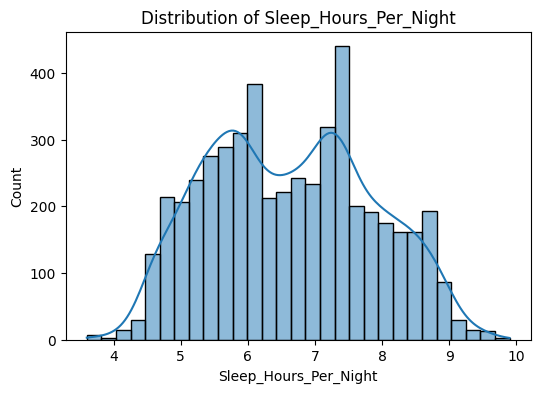

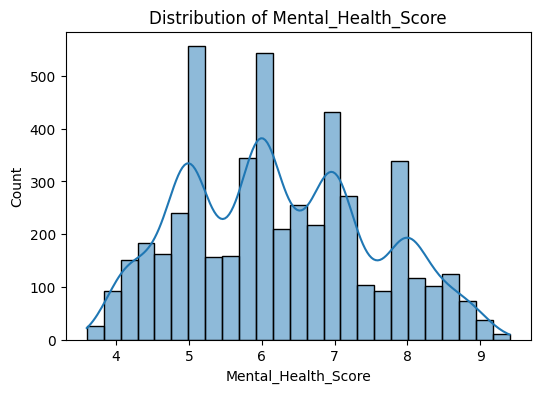

In [41]:
for col in num_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

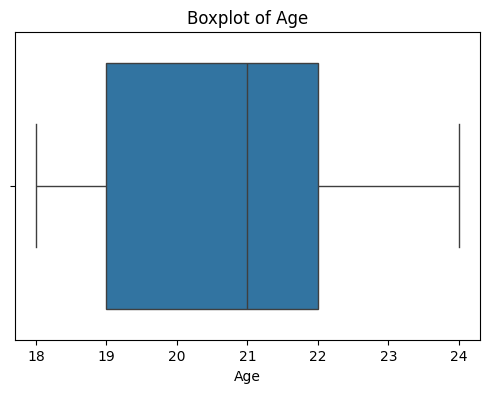

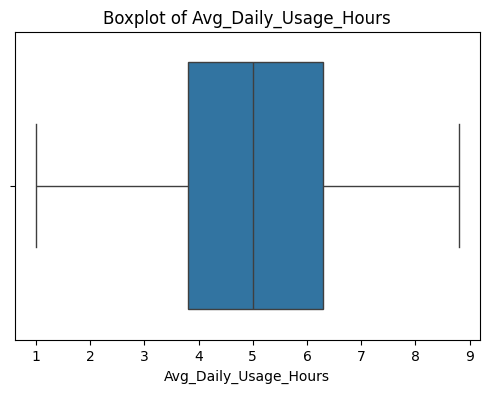

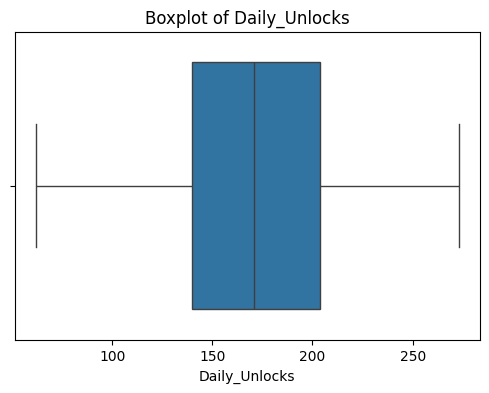

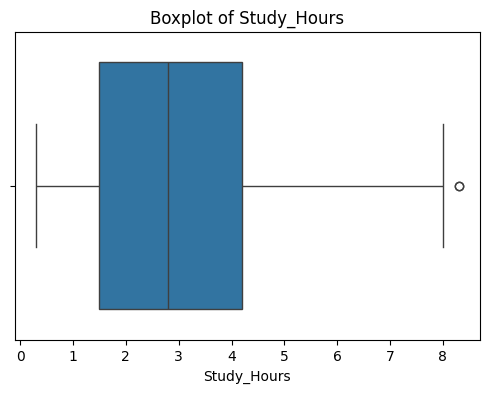

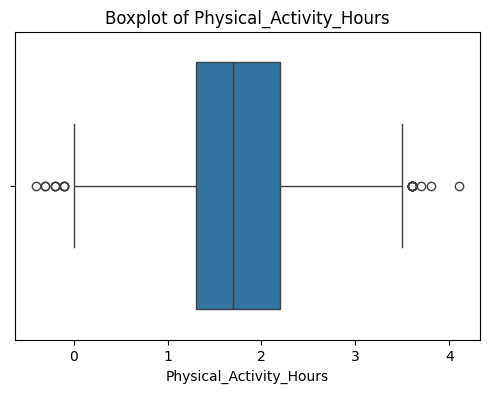

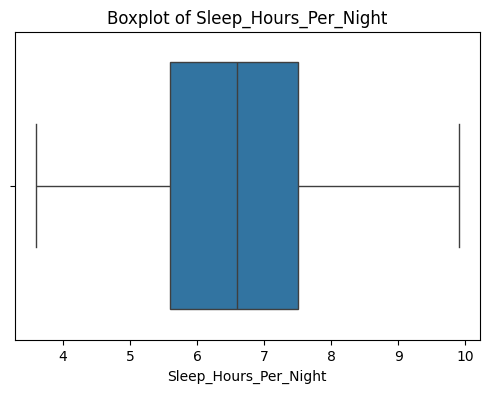

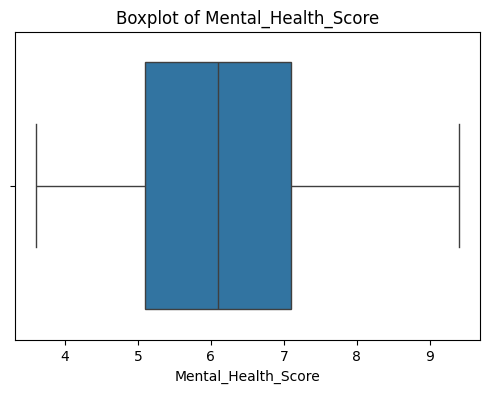

In [42]:
for col in num_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

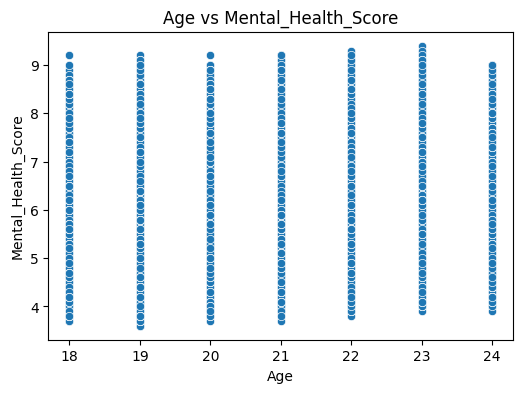

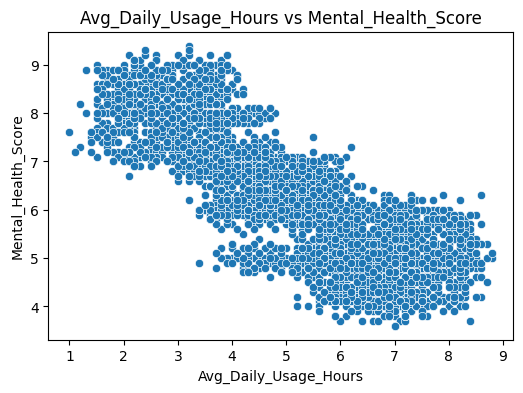

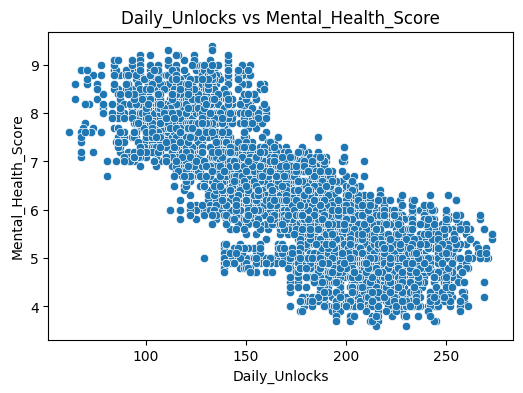

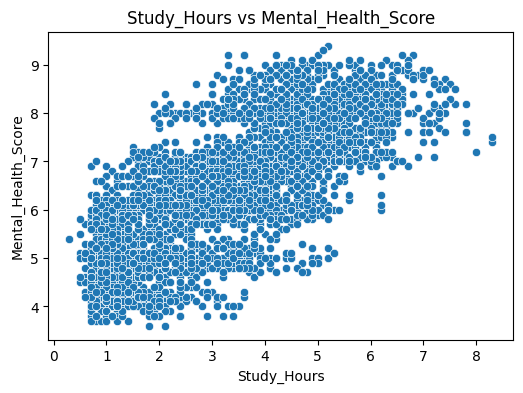

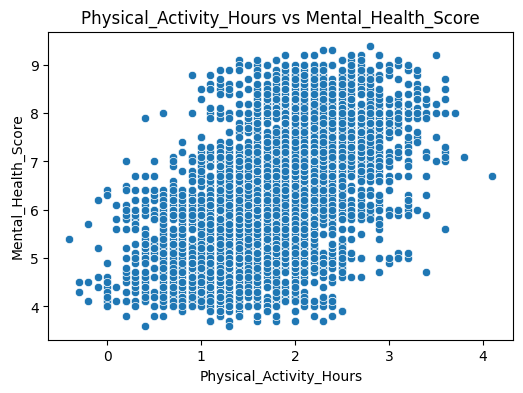

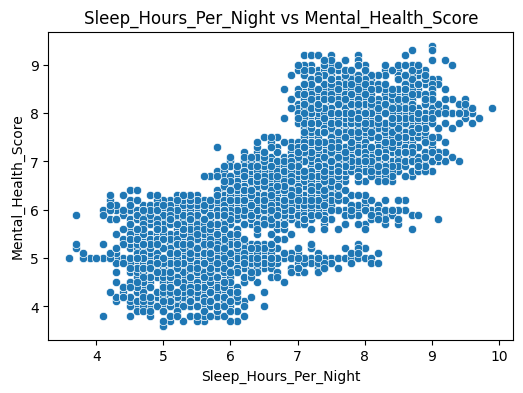

In [43]:
for col in num_features:
    if col != 'Mental_Health_Score':
        plt.figure(figsize=(6, 4))
        sns.scatterplot(data=df, x=col, y='Mental_Health_Score')
        plt.title(f"{col} vs {'Mental_Health_Score'}")
        plt.show()

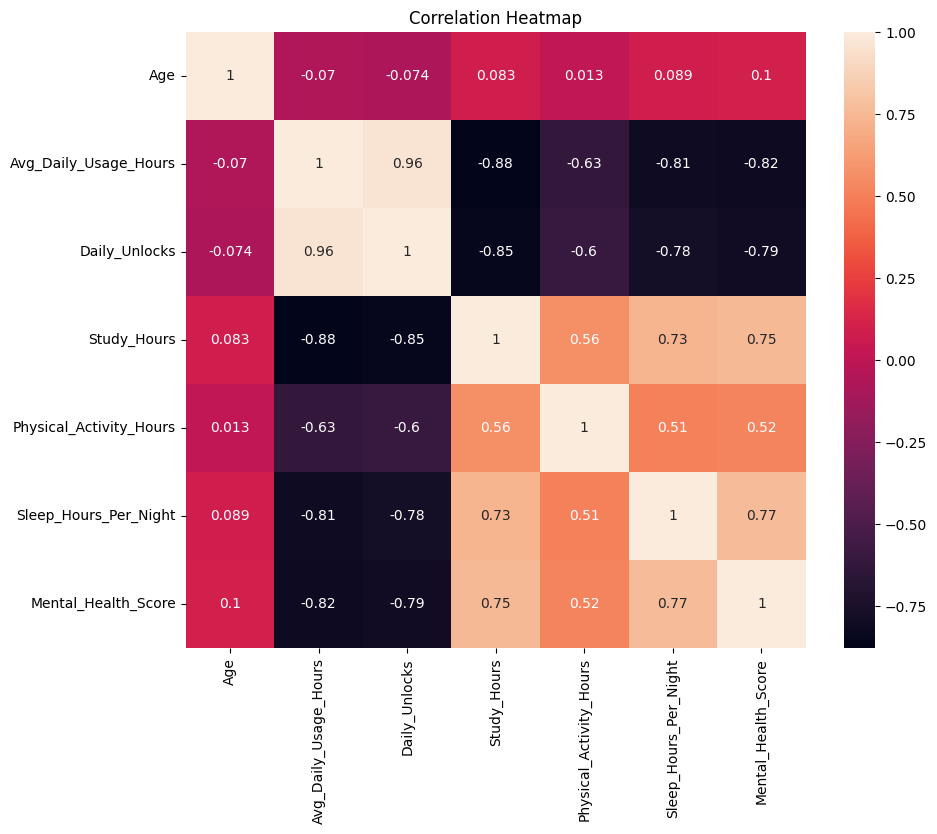

In [44]:
# Examine correlations among numerical variables
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True)
plt.title('Correlation Heatmap')
plt.show()

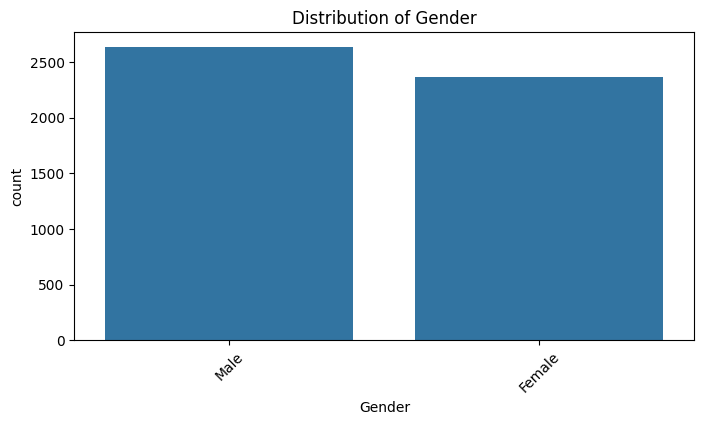

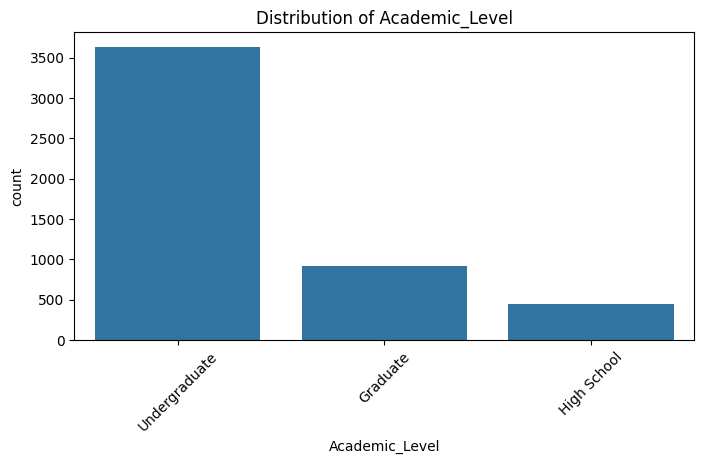

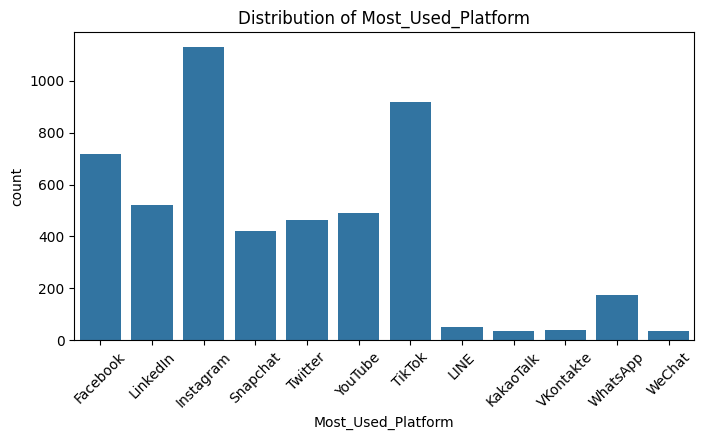

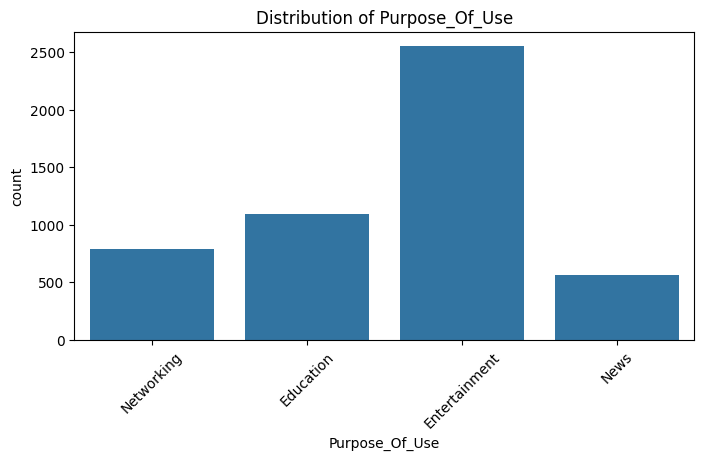

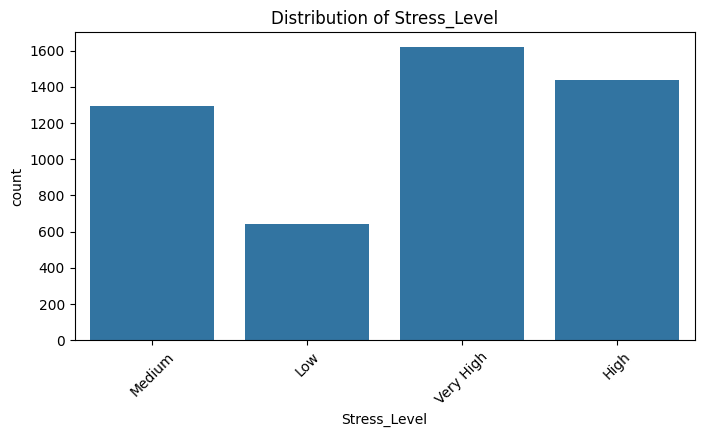

In [45]:
for col in cat_features:
  if col != 'Country':
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

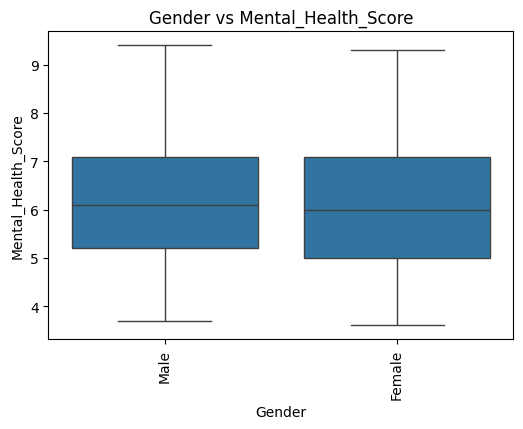

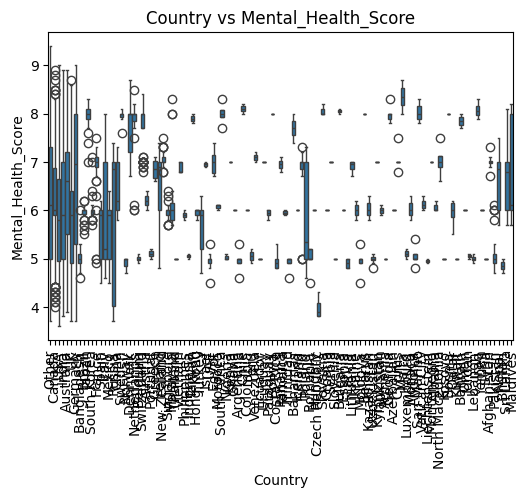

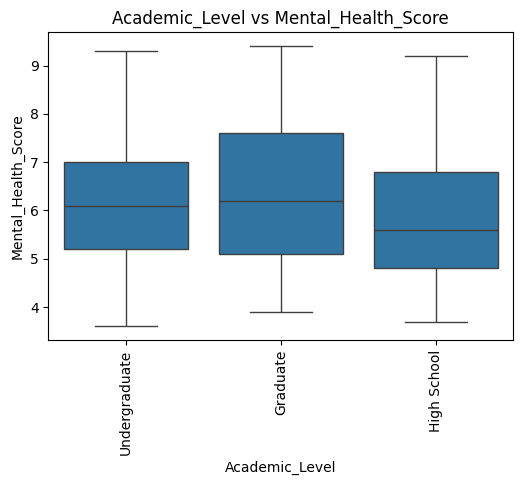

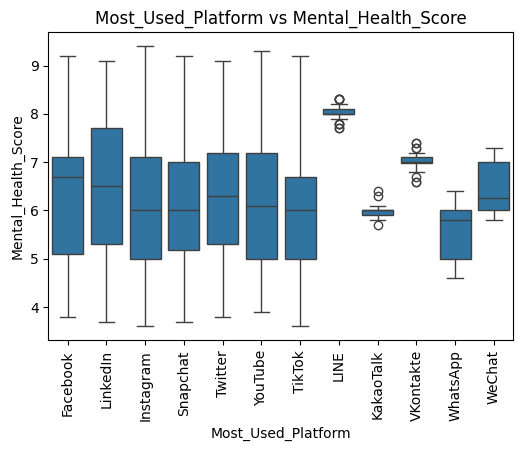

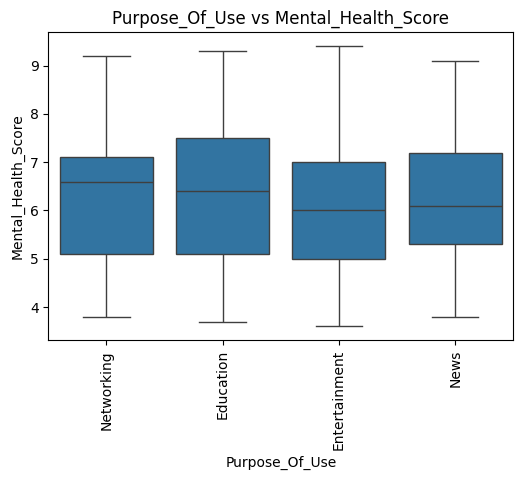

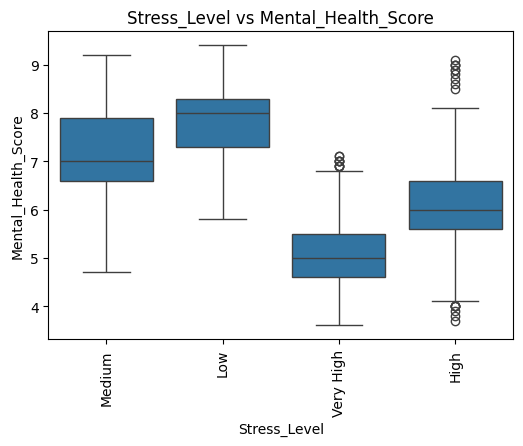

In [46]:
for col in cat_features:
  plt.figure(figsize=(6, 4))
  sns.boxplot(data=df, x=col, y='Mental_Health_Score')
  plt.title(f"{col} vs {'Mental_Health_Score'}")
  plt.xticks(rotation=90)
  plt.show()

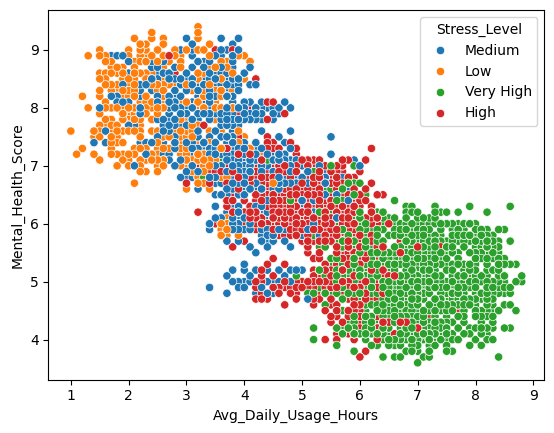

In [47]:
# Examine usage and mental-health score while distinguishing stress levels
sns.scatterplot(
    data=df,
    x="Avg_Daily_Usage_Hours",
    y="Mental_Health_Score",
    hue="Stress_Level"
)

plt.show()

In [48]:
df.groupby("Stress_Level")["Mental_Health_Score"].agg(["mean", "median", "std", "min", "max"])

,mean,median,std,min,max
Stress_Level,,,,,
High,6.025417,6.0,0.830395,3.7,9.1
Low,7.840217,8.0,0.723187,5.8,9.4
Medium,7.135907,7.0,0.916431,4.7,9.2
Very High,5.051326,5.0,0.663711,3.6,7.1


## 4. Exploratory Data Analysis

EDA helps us understand target distribution, feature relationships, categorical patterns, and unusual observations. The goal is to identify useful patterns and potential data-quality issues.

In [49]:
df.groupby("Stress_Level")["Avg_Daily_Usage_Hours"].agg(["mean", "median", "std", "min", "max"])

,mean,median,std,min,max
Stress_Level,,,,,
High,5.188403,5.2,0.756127,2.6,7.7
Low,2.776398,2.8,0.730497,1.0,4.5
Medium,3.862239,3.9,0.785840,1.4,6.3
Very High,6.866996,6.9,0.852840,3.3,8.8


In [50]:
df["Country"].value_counts().head(10)

,count
Country,
Other,1880
India,389
USA,355
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


## 5. Outlier Detection

Use the **IQR (Interquartile Range)** method to identify potential outliers in numerical columns.

`IQR = Q3 - Q1`

Potential outliers lie below `Q1 - 1.5 × IQR` or above `Q3 + 1.5 × IQR`.

In [52]:
# Calculate IQR-based outlier bounds for numerical columns
Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = (num_features < lower_bound) | (num_features > upper_bound)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


## 6. Data Cleaning

Remove duplicate rows and correct the negative values found in `Physical_Activity_Hours` by setting the minimum value to zero.

In [54]:
# Remove duplicates and correct impossible negative physical-activity values
df = df.drop_duplicates()

df["Physical_Activity_Hours"] = df['Physical_Activity_Hours'].clip(lower=0)

In [55]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


## 7. Check Skewness

Skewness describes the asymmetry of a numerical distribution. We inspect it to decide whether a transformation may be useful.

In [67]:
# Measure skewness of numerical features
num_features.skew()

,0
Age,0.155325
Avg_Daily_Usage_Hours,0.005606
Daily_Unlocks,0.002351
Study_Hours,0.435819
Physical_Activity_Hours,0.039971
Sleep_Hours_Per_Night,0.124050
Mental_Health_Score,0.206567


In [58]:
# Find the most frequent countries, excluding the existing Other category
country_counts = (df.loc[df["Country"] != "Other", "Country"].value_counts())
country_counts.head(10)

,count
Country,
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94
France,87


## 8. Define Features and Target

Separate the predictors (`X`) from the target (`y`). The target is excluded from `X` because it is the value the model must predict.

In [60]:
# Separate predictors from the target
X = df.drop('Mental_Health_Score', axis=1)
y = df['Mental_Health_Score']

## 9. Train-Test Split

Split the data into training and testing sets. The training set is used to learn the preprocessing and model parameters, while the test set is kept for final evaluation. A fixed `random_state` makes the split reproducible.

In [61]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [63]:
X_train.shape

(3498, 12)

In [64]:
X_test.shape

(1500, 12)

In [65]:
y_train.shape

(3498,)

In [66]:
y_test.shape

(1500,)

## 10. Reduce Country Cardinality

`Country` contains many unique categories. Keep the 10 most frequent countries from the **training data** and group all remaining countries into `Other`. Using only training data avoids leaking information from the test set.

In [69]:
# Determine the top 10 countries using training data only
# Find top 10 countries from training data
top_10_countries = (X_train.loc[X_train["Country"] != "Other", "Country"].value_counts().head(10))
top_10_countries

,count
Country,
India,260
USA,248
Canada,167
UK,135
Australia,130
Germany,98
France,67
Mexico,66
Turkey,66


In [70]:
# Map every country outside the top 10 to Other
# Function to group countries
def group_country(country):
  if country in top_10_countries.index:
    return country
  else:
    return "Other"

In [71]:
# Apply the same country grouping rule to train and test data
# Apply to both training and testing data
X_train["Country"] = X_train["Country"].apply(group_country)
X_test["Country"] = X_test["Country"].apply(group_country)

In [72]:
# Check the result
print("Training data:")
print(X_train["Country"].value_counts())

Training data:
Country
Other        2199
India         260
USA           248
Canada        167
UK            135
Australia     130
Germany        98
France         67
Mexico         66
Turkey         66
Spain          62
Name: count, dtype: int64


In [73]:
print("\nTesting data:")
print(X_test["Country"].value_counts())


Testing data:
Country
Other        949
India        129
USA          106
Australia     68
Canada        63
UK            50
Germany       38
Turkey        28
Mexico        28
Spain         21
France        20
Name: count, dtype: int64


In [74]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

## 11. Feature Groups for Preprocessing

Different feature types require different preprocessing:

- `Study_Hours` → log transformation + scaling
- Other numerical features → scaling
- `Stress_Level` → ordinal encoding because the categories have a natural order
- Other categorical features → one-hot encoding

In [87]:
skew_cols          = ["Study_Hours"]
other_numeric_cols = ["Age", "Avg_Daily_Usage_Hours", "Daily_Unlocks","Physical_Activity_Hours","Sleep_Hours_Per_Night"]
ordinal_col        = ['Stress_Level']
categorical_col    = ["Gender", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "Country"]

## 12. Build the Preprocessing Pipeline

Use separate pipelines for each feature group and combine them with `ColumnTransformer`. The imputers make the pipeline robust to missing values, while scaling and encoding prepare the features for the models.

In [88]:
# Build preprocessing pipelines for each feature type
# Skewed features
skew_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

# Numeric features
plain_numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Ordinal features
ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]))
])

# Categorical features
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])


preprocessor = ColumnTransformer(transformers=[
    ('skew', skew_pipeline, skew_cols),
    ('plain_numeric', plain_numeric_pipeline, other_numeric_cols),
    ('ordinal', ordinal_pipeline, ordinal_col),
    ('categorical', categorical_pipeline, categorical_col)
])

In [89]:
preprocessor

ColumnTransformer(transformers=[('skew',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('log',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scaler', StandardScaler())]),
                                 ['Study_Hours']),
                                ('plain_numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Avg_Daily_Usage_Hours',
                                  'Daily_Unlocks...
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High',
                                                                              'Very '
                                                                              'High']]))]),
                                 ['Stress_Level']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['Gender', 'Academic_Level',
                                  'Most_Used_Platform', 'Purpose_Of_Use',
                                  'Country'])])

## 13. Linear Regression

Train **Linear Regression** as a baseline model. A baseline gives us a reference point for judging more complex models.

In [90]:
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

pipeline_lr

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('skew',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('log',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Study_Hours']),
                                                 ('plain_numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Avg_D...
                                                                  ('encoder',
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Medium',
                                                                                               'High',
                                                                                               'Very '
                                                                                               'High']]))]),
                                                  ['Stress_Level']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Gender', 'Academic_Level',
                                                   'Most_Used_Platform',
                                                   'Purpose_Of_Use',
                                                   'Country'])])),
                ('model', LinearRegression())])

In [94]:
# Fit the complete preprocessing + Linear Regression pipeline
pipeline_lr.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('skew',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('log',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Study_Hours']),
                                                 ('plain_numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Avg_D...
                                                                  ('encoder',
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Medium',
                                                                                               'High',
                                                                                               'Very '
                                                                                               'High']]))]),
                                                  ['Stress_Level']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Gender', 'Academic_Level',
                                                   'Most_Used_Platform',
                                                   'Purpose_Of_Use',
                                                   'Country'])])),
                ('model', LinearRegression())])

In [95]:
# Generate predictions for both training and testing data
lr_pred = pipeline_lr.predict(X_test)
lr_pred_train = pipeline_lr.predict(X_train)

In [100]:
# Evaluate Linear Regression
lr_r2_testing = r2_score(y_test, lr_pred)
lr_r2_training = r2_score(y_train, lr_pred_train)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)

print(f"R2 on training data: {lr_r2_training}")
print(f"R2 on testing data: {lr_r2_testing}")
print(f"MAE: {lr_mae}")
print(f"MSE: {lr_mse}")
print(f"RMSE: {lr_rmse}")

R2 on training data: 0.7284451141767213
R2 on testing data: 0.7431949512902989
MAE: 0.5302565031464506
MSE: 0.4510465107128489
RMSE: 0.67159996330617


## 14. Ridge Regression

Ridge Regression adds **L2 regularization** to Linear Regression. `alpha` controls the strength of the regularization.

In [102]:
# Train and evaluate Ridge Regression
from sklearn.linear_model import Ridge

ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_pipeline.fit(X_train, y_train)

ridge_pred = ridge_pipeline.predict(X_test)
ridge_pred_train = ridge_pipeline.predict(X_train)

ridge_r2_training = r2_score(y_train, ridge_pred_train)
ridge_r2_testing = r2_score(y_test, ridge_pred)

ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)

print(f"R² on training data: {ridge_r2_training}")
print(f"R² on testing data: {ridge_r2_testing}")
print(f"MAE: {ridge_mae}")
print(f"MSE: {ridge_mse}")
print(f"RMSE: {ridge_rmse}")

R² on training data: 0.7284236026759461
R² on testing data: 0.7432013656273765
MAE: 0.5302767522748331
MSE: 0.4510352447179942
RMSE: 0.6715915758241717


## 15. Lasso Regression

Lasso Regression adds **L1 regularization**. It can shrink some coefficients toward zero, which can act as a form of feature selection.

In [103]:
# Train and evaluate Lasso Regression
from sklearn.linear_model import Lasso

lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=0.01))
])

lasso_pipeline.fit(X_train, y_train)

lasso_pred = lasso_pipeline.predict(X_test)
lasso_pred_train = lasso_pipeline.predict(X_train)

lasso_r2_training = r2_score(y_train, lasso_pred_train)
lasso_r2_testing = r2_score(y_test, lasso_pred)

lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)

print(f"R² on training data: {lasso_r2_training}")
print(f"R² on testing data: {lasso_r2_testing}")
print(f"MAE: {lasso_mae}")
print(f"MSE: {lasso_mse}")
print(f"RMSE: {lasso_rmse}")

R² on training data: 0.7110033772938071
R² on testing data: 0.730572422663611
MAE: 0.5481199869322922
MSE: 0.4732164311332084
RMSE: 0.6879072838204349


## 16. Random Forest Regression

Train a **Random Forest Regressor**. Random Forest can capture non-linear relationships and interactions that a linear model may not capture well.

In [110]:
# Train and evaluate the Random Forest baseline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor())
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)
rf_pred_train = rf_pipeline.predict(X_train)

rf_r2_training = r2_score(y_train, rf_pred_train)
rf_r2_testing = r2_score(y_test, rf_pred)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)

print(f"R² on training data: {rf_r2_training}")
print(f"R² on testing data: {rf_r2_testing}")
print(f"MAE: {rf_mae}")
print(f"MSE: {rf_mse}")
print(f"RMSE: {rf_rmse}")

R² on training data: 0.9812266679636915
R² on testing data: 0.8800654095670282
MAE: 0.34179200000000004
MSE: 0.21065037
RMSE: 0.4589666327741048


## 17. Random Forest Hyperparameter Tuning

Use `RandomizedSearchCV` with cross-validation to test different Random Forest hyperparameter combinations and find a promising configuration.

In [115]:
# Search for a better Random Forest configuration using cross-validation
from sklearn.model_selection import RandomizedSearchCV


param_grid = {
    'model__n_estimators'       : [100, 200, 300],
    'model__max_depth'          : [5, 10, 20],
    'model__min_samples_split'  : [2, 5, 10],
    'model__min_samples_leaf'   : [1, 2, 4]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=30,
    cv=5,
    scoring='r2',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('skew',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('log',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('plain_numeric',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler'...
                                                                                                              handle_unknown='ignore'))]),
                                                                               ['Gender',
                                                                                'Academic_Level',
                                                                                'Most_Used_Platform',
                                                                                'Purpose_Of_Use',
                                                                                'Country'])])),
                                             ('model',
                                              RandomForestRegressor())]),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'model__max_depth': [5, 10, 20],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300]},
                   random_state=42, scoring='r2', verbose=2)

In [116]:
print("Best parameters:")
print(random_search.best_params_)

print("\nBest CV R²:")
print(random_search.best_score_)

Best parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': 20}

Best CV R²:
0.8530559793167166


In [126]:
# Evaluate the best Random Forest configuration found by RandomizedSearchCV
best_rf = random_search.best_estimator_

rf_tuned_pred = best_rf.predict(X_test)
rf_tuned_pred_train = best_rf.predict(X_train)

rf_tuned_r2_training = r2_score(y_train, rf_tuned_pred_train)
rf_tuned_r2_testing = r2_score(y_test, rf_tuned_pred)

rf_tuned_mae = mean_absolute_error(y_test, rf_tuned_pred)
rf_tuned_mse = mean_squared_error(y_test, rf_tuned_pred)
rf_tuned_rmse = np.sqrt(rf_mse)

print(f"R² on training data: {rf_tuned_r2_training}")
print(f"R² on testing data: {rf_tuned_r2_testing}")
print(f"MAE: {rf_tuned_mae}")
print(f"MSE: {rf_tuned_mse}")
print(f"RMSE: {rf_tuned_rmse}")

R² on training data: 0.979780236301152
R² on testing data: 0.8772229763808632
MAE: 0.345966787924619
MSE: 0.21564275460067575
RMSE: 0.4589666327741048


## 18. Compare Model Performance

Compare the models using test-set metrics:

- **R²:** higher is better
- **MAE:** lower is better
- **MSE:** lower is better
- **RMSE:** lower is better and is in the same units as the target

In [128]:
# Combine the test-set metrics into one comparison table
model_results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression", "Random Forest", "Tuned Random Forest"],
    "R2 Score": [lr_r2_testing, ridge_r2_testing, lasso_r2_testing, rf_r2_testing, rf_tuned_r2_testing],
    "MAE": [lr_mae, ridge_mae, lasso_mae, rf_mae, rf_tuned_mae],
    "MSE": [lr_mse, ridge_mse, lasso_mse, rf_mse, rf_tuned_mse],
    "RMSE": [lr_rmse, ridge_rmse, lasso_rmse, rf_rmse, rf_tuned_rmse]
})
print(model_results)

                 Model  R2 Score       MAE       MSE      RMSE
0    Linear Regression  0.743195  0.530257  0.451047  0.671600
1     Ridge Regression  0.743201  0.530277  0.451035  0.671592
2     Lasso Regression  0.730572  0.548120  0.473216  0.687907
3        Random Forest  0.880065  0.341792  0.210650  0.458967
4  Tuned Random Forest  0.877223  0.345967  0.215643  0.458967


## 19. Save the Best Model

Save the complete Random Forest pipeline with `joblib`. Saving the pipeline preserves both preprocessing and the trained model, so raw input data can later be passed directly to it.

In [129]:
# Save the complete preprocessing + model pipeline
import joblib

joblib.dump(rf_pipeline, 'mental_health_model.pkl')

['mental_health.pkl']

## 20. Load the Saved Model

Load the saved pipeline for prediction on new student data.

**Important:** this cell currently uses `mental_health.pkl`, while the previous cell saves `mental_health_model.pkl`. The filenames should match.

In [130]:
# Load the saved pipeline for prediction
model = joblib.load("/content/mental_health.pkl")

## 21. Test the Model on a New Student

Create one example student as a DataFrame. The feature names and categorical values must match those used during training.

In [131]:
# Example input for one new student
new_student = pd.DataFrame({
    "Age": [21],
    "Gender": ["Male"],
    "Country": ["India"],
    "Academic_Level": ["Undergraduate"],
    "Avg_Daily_Usage_Hours": [5.2],
    "Daily_Unlocks": [80],
    "Most_Used_Platform": ["Instagram"],
    "Purpose_Of_Use": ["Entertainment"],
    "Study_Hours": [3.5],
    "Physical_Activity_Hours": [1.0],
    "Sleep_Hours_Per_Night": [7.0],
    "Stress_Level": ["High"]
})

## 22. Make a Prediction

Pass the new student's data through the saved pipeline and display the predicted Mental Health Score.

In [133]:
# Predict the student's Mental Health Score
prediction = model.predict(new_student)

print(f"Predicted Mental Health Score: {prediction[0]:.2f}")

Predicted Mental Health Score: 5.77
